In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.initializers import RandomNormal, GlorotUniform, HeNormal
import matplotlib.pyplot as plt

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
# X_train = X_train / 255.0
# X_test = X_test / 255.0

X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

X_test_small = X_test[:2000]
y_test_small = y_test[:2000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Model Architechture

def create_model(weight_init, optimizer):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_initializer=weight_init),
        Dense(64, activation='relu', kernel_initializer=weight_init),
        Dense(10, activation='softmax', kernel_initializer=weight_init)
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Configurations

initializations = {
    "Random Normal": RandomNormal(mean=0.0, stddev=0.05),
    "Xavier (Glorot)": GlorotUniform(),
    "He Normal": HeNormal()
}

optimizers = {
    "SGD": lambda: tf.keras.optimizers.SGD(learning_rate=0.01),
    "Adam": lambda: tf.keras.optimizers.Adam(learning_rate=0.001)
}

#EPOCHS = 10
EPOCHS = 3

In [ ]:
# Training Models

history_records = {}

for init_name, init in initializations.items():
    for opt_name, opt_fn in optimizers.items():
        print(f"\nTraining with {init_name} + {opt_name}")

        model = create_model(init, opt_fn())

        history = model.fit(
            X_train_small, y_train_small,
            validation_data=(X_test_small, y_test_small),
            epochs=EPOCHS,
            batch_size=128,
            verbose=1
        )

        history_records[f"{init_name} + {opt_name}"] = history

        # Clear session AFTER training each model
        tf.keras.backend.clear_session()



Training with Random Normal + SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4307 - loss: 8.6735 - val_accuracy: 0.7105 - val_loss: 1.0234
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8596 - loss: 0.4665 - val_accuracy: 0.8050 - val_loss: 0.6500
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9006 - loss: 0.3214 - val_accuracy: 0.8165 - val_loss: 0.6160

Training with Random Normal + Adam
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5796 - loss: 3.0676 - val_accuracy: 0.8155 - val_loss: 0.6614
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9017 - loss: 0.3455 - val_accuracy: 0.8685 - val_loss: 0.4761
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9443 - loss: 0.1949 - val_accuracy: 0.8865 - val_loss: 0.4160

Training with Xavier (Glorot) + SGD
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1116 - loss: 3329.2087 - val_accuracy: 0.1175 - val_loss: 2.3434
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

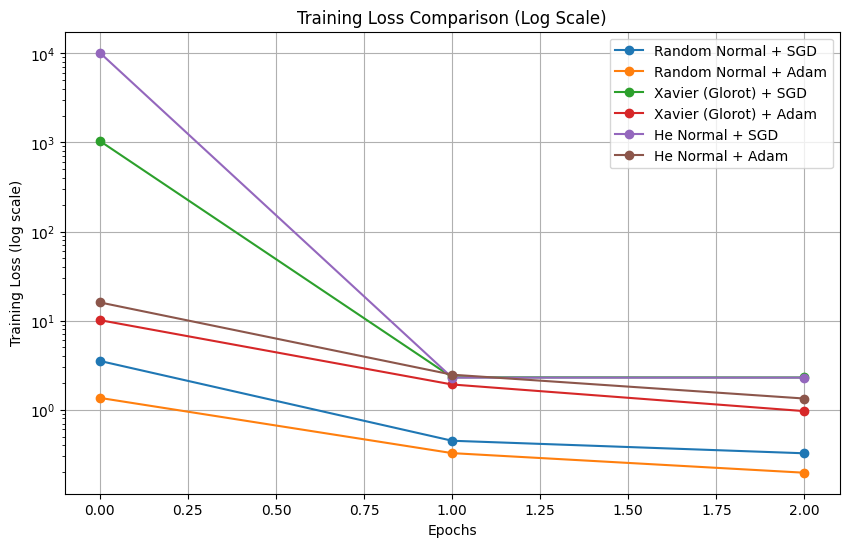

In [ ]:
# Training Loss Graph

plt.figure(figsize=(10, 6))

for key, history in history_records.items():
    plt.plot(history.history['loss'], marker='o', label=key)

plt.xlabel("Epochs")
plt.ylabel("Training Loss (log scale)")
plt.yscale("log")          # ✅ THIS LINE FIXES IT
plt.title("Training Loss Comparison (Log Scale)")
plt.legend()
plt.grid(True)
plt.show()

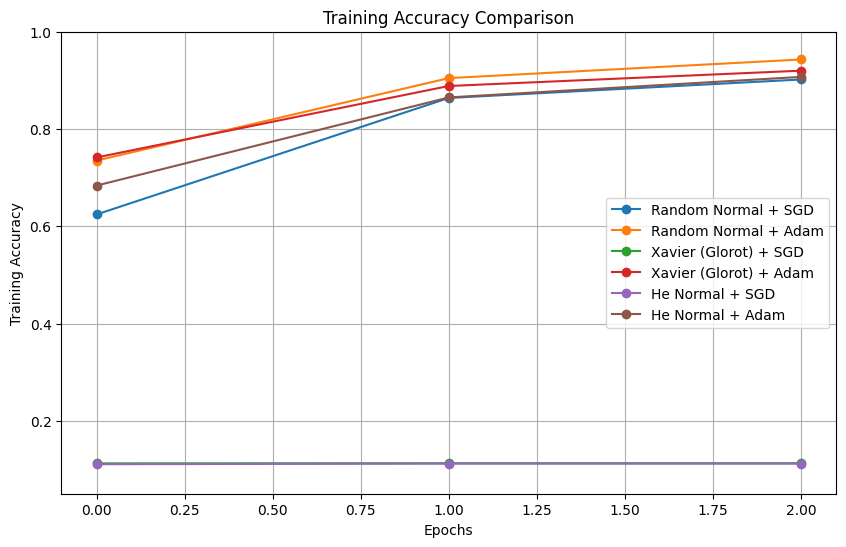

In [ ]:
# Training Accuracy Graph

plt.figure(figsize=(10, 6))

for key, history in history_records.items():
    plt.plot(history.history['accuracy'], marker='o', label=key)

plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.ylim(0.05, 1.0)        # ✅ zoom so low-accuracy lines are visible
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy Output

print("\nFinal Test Accuracies :")
for key, history in history_records.items():
    final_acc = history.history['val_accuracy'][-1]
    print(f"{key} : {final_acc:.4f}")


Final Test Accuracies :
Random Normal + SGD : 0.8165
Random Normal + Adam : 0.8865
Xavier (Glorot) + SGD : 0.1175
Xavier (Glorot) + Adam : 0.8500
He Normal + SGD : 0.1110
He Normal + Adam : 0.8395


In [ ]:
# Final Accuracy Table (Validation Accuracy)

import pandas as pd

final_results = []

for key, history in history_records.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    final_results.append({
        "Initialization + Optimizer": key,
        "Final Training Accuracy": round(final_train_acc, 4),
        "Final Validation Accuracy": round(final_val_acc, 4)
    })

results_df = pd.DataFrame(final_results)
results_df
print(results_df.to_string(index=False))

Initialization + Optimizer  Final Training Accuracy  Final Validation Accuracy
       Random Normal + SGD                   0.9018                     0.8165
      Random Normal + Adam                   0.9429                     0.8865
     Xavier (Glorot) + SGD                   0.1127                     0.1175
    Xavier (Glorot) + Adam                   0.9199                     0.8500
           He Normal + SGD                   0.1119                     0.1110
          He Normal + Adam                   0.9071                     0.8395
